**Part 1**

**Mount Google Drive in Colab**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Define Dataset Path**

In [56]:
dataset_path = "/content/drive/My Drive/ImageDataset"

**Load Images Using TensorFlow**

In [57]:
import tensorflow as tf

img_height = 180
img_width = 180
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_path,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_path,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size
)

Found 5895 files belonging to 20 classes.
Using 4716 files for training.
Found 5895 files belonging to 20 classes.
Using 1179 files for validation.


**View Class Names**

In [58]:
class_names = train_ds.class_names
print(class_names)

['avocado', 'banana', 'betel', 'cacao', 'cassava', 'corn', 'durian', 'eggplant', 'guava', 'jackfruit', 'lanzones', 'mahogany', 'mango', 'narra', 'neem', 'papaya', 'rambutan', 'sugarcane', 'sweet_potato', 'taro']


**Part 2**

**Optimize Dataset Performance**

In [59]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

**Build the CNN Model**

In [60]:
from tensorflow.keras import layers, models
model = models.Sequential([
   layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
   layers.Conv2D(16, 3, padding='same', activation='relu'),
   layers.MaxPooling2D(),
   layers.Conv2D(32, 3, padding='same', activation='relu'),
   layers.MaxPooling2D(),
   layers.Conv2D(64, 3, padding='same', activation='relu'),
   layers.MaxPooling2D(),
   layers.Flatten(),
   layers.Dense(128, activation='relu'),
   layers.Dense(len(class_names))
])

**Compile the Model**

In [61]:
model.compile(
   optimizer='adam',
   loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
   metrics=['accuracy']
)

**Train the Model**

In [62]:
epochs = 20
history = model.fit(
   train_ds,
   validation_data=val_ds,
   epochs=epochs
)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 1728s 4s/step - accuracy: 0.0825 - loss: 2.9577 - val_accuracy: 0.1069 - val_loss: 2.8539
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.2152 - loss: 2.5875 - val_accuracy: 0.2375 - val_loss: 2.5291
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.3764 - loss: 2.0217 - val_accuracy: 0.3036 - val_loss: 2.3530
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.5791 - loss: 1.3530 - val_accuracy: 0.3274 - val_loss: 2.2605
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 177s 1s/step - accuracy: 0.7816 - loss: 0.7076 - val_accuracy: 0.3291 - val_loss: 2.7341
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 181s 1s/step - accuracy: 0.9016 - loss: 0.3372 - val_accuracy: 0.3418 - val_loss: 3.4698
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9559 - loss: 0.1437 - val_accuracy: 0.3147 - val_loss: 4.4233
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9731 - loss: 0.0924 - val_acc

**Evaluate Model Performance**

In [63]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)

37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 340ms/step - accuracy: 0.3545 - loss: 5.8999
Validation Accuracy: 0.3545377552509308


**Test with a New Image**

In [64]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array

img_path = "/content/drive/My Drive/test.jpg"
img = load_img(img_path, target_size=(img_height, img_width))
img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])
print("Predicted Class:", class_names[np.argmax(score)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step
Predicted Class: mahogany


**Part 3**


**Plot Training vs Validation Accuracy and Loss**

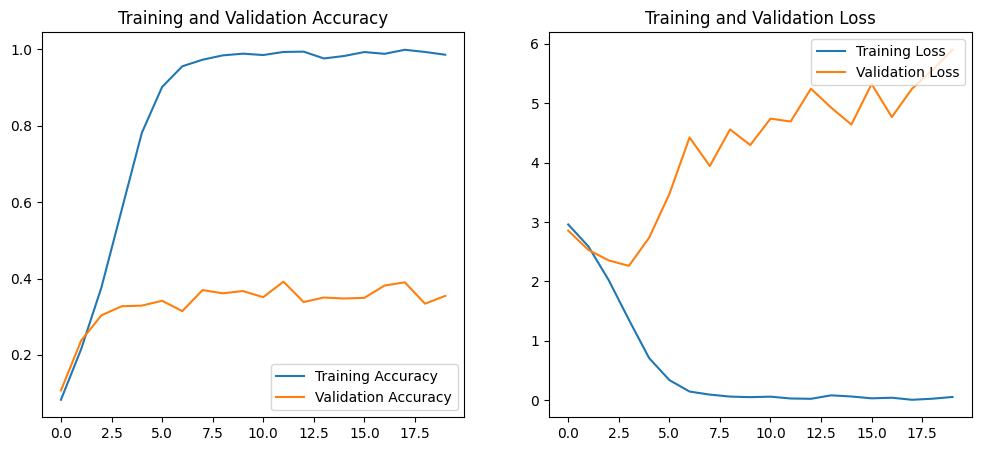

In [65]:
import matplotlib.pyplot as plt
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))
plt.figure(figsize=(12, 5))
# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

**Part 4**

**Create Data Augmentation Layer**

In [66]:
data_augmentation = tf.keras.Sequential([
   layers.RandomFlip("horizontal"),
   layers.RandomRotation(0.1),
   layers.RandomZoom(0.1),
])

**Visualize Augmented Images**

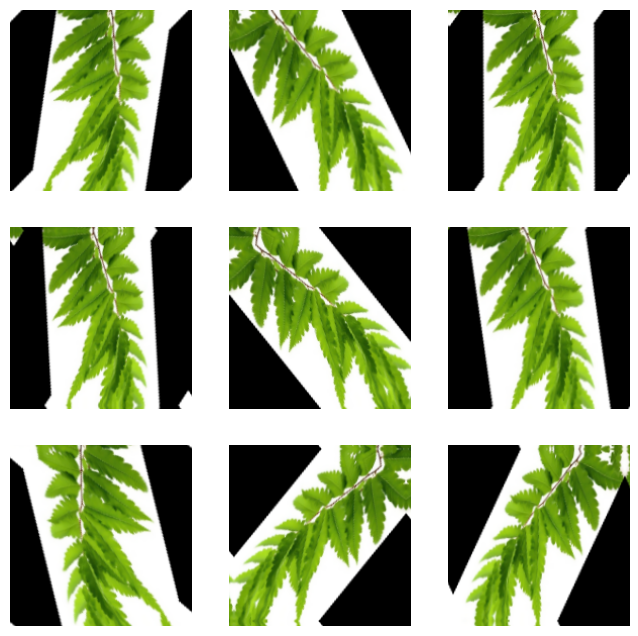

In [67]:
import matplotlib.pyplot as plt

for images, _ in train_ds.take(1):
   plt.figure(figsize=(8, 8))
   for i in range(9):
       augmented_images = data_augmentation(images)
       ax = plt.subplot(3, 3, i + 1)
       plt.imshow(augmented_images[0].numpy().astype("uint8"))
       plt.axis("off")

**Part 5**

**Build an improved CNN Model**

In [68]:
model = models.Sequential([
   data_augmentation,
   layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),

   layers.Conv2D(16, 3, padding='same', activation='relu'),
   layers.MaxPooling2D(),

   layers.Conv2D(32, 3, padding='same', activation='relu'),
   layers.MaxPooling2D(),

   layers.Conv2D(64, 3, padding='same', activation='relu'),
   layers.MaxPooling2D(),

   layers.Dropout(0.3),
   layers.Flatten(),
   layers.Dense(128, activation='relu'),
   layers.Dropout(0.3),
   layers.Dense(len(class_names))
])

**Part 6**

**Compile Model**

In [69]:
model.compile(
optimizer='adam',
loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
metrics=['accuracy']
)

**Train Model**

In [73]:
epochs = 20
history = model.fit(
train_ds,
validation_data=val_ds,
epochs=epochs
)

Epoch 1/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.8516 - loss: 0.4645 - val_accuracy: 0.8007 - val_loss: 0.8824
Epoch 2/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 205s 1s/step - accuracy: 0.8463 - loss: 0.4637 - val_accuracy: 0.8338 - val_loss: 0.7951
Epoch 3/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 214s 1s/step - accuracy: 0.8526 - loss: 0.4264 - val_accuracy: 0.8244 - val_loss: 0.7509
Epoch 4/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.8484 - loss: 0.4686 - val_accuracy: 0.8363 - val_loss: 0.6301
Epoch 5/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 263s 1s/step - accuracy: 0.8647 - loss: 0.4303 - val_accuracy: 0.8007 - val_loss: 0.9108
Epoch 6/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.8641 - loss: 0.4168 - val_accuracy: 0.8473 - val_loss: 0.6230
Epoch 7/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.8598 - loss: 0.4260 - val_accuracy: 0.8736 - val_loss: 0.5534
Epoch 8/20
148/148 ━━━━━━━━━━━━━━━━━━━━ 246s 1s/step - accuracy: 0.8651 - loss: 0.4120 - val_accu

**Part 7**

**Step-by-Step Procedure**

In [78]:
img_path = "/content/drive/My Drive/test1.jpg"
img = load_img(img_path, target_size=(img_height, img_width))
img_array = img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])
print("Predicted Class:", class_names[np.argmax(score)])
print("Confidence:", round(100 * np.max(score), 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Predicted Class: papaya
Confidence: 77.41 %


**Part 8: Save and Reuse the Model**

In [79]:
model.save("/content/drive/My Drive/my-image_classifier.keras")

In [80]:
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/my-image_classifier.keras")
print("Model loaded successfully!")

Model loaded successfully!
